In [1]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load data
files = glob.glob("../data/sampled/sample_*.parquet")
dfs = [pd.read_parquet(f) for f in files]
df = pd.concat(dfs, ignore_index=True)

# ---- Same feature engineering as improve_model.py ----
df['total_extras'] = df['tips'] + df['tolls'] + df['congestion_surcharge'] + df['airport_fee']
df['fare_per_mile'] = df['driver_pay'] / df['trip_miles'].replace(0, np.nan)
df['fare_per_minute'] = df['driver_pay'] / df['trip_minutes'].replace(0, np.nan)
df['miles_per_minute'] = df['trip_miles'] / df['trip_minutes'].replace(0, np.nan)
df['is_long_trip'] = (df['trip_miles'] > df['trip_miles'].quantile(0.75)).astype(int)
df['is_short_trip'] = (df['trip_miles'] < df['trip_miles'].quantile(0.25)).astype(int)
df['is_rush_hour'] = df['pickup_hour'].isin([7,8,9,16,17,18,19]).astype(int)
df['is_night'] = df['pickup_hour'].isin([22,23,0,1,2,3,4,5]).astype(int)
df['is_morning'] = df['pickup_hour'].isin([6,7,8,9,10,11]).astype(int)

def get_time_period(hour):
    if hour in [6,7,8,9]: return 0
    elif hour in [10,11,12,13,14,15]: return 1
    elif hour in [16,17,18,19]: return 2
    elif hour in [20,21,22,23]: return 3
    else: return 4

df['time_period'] = df['pickup_hour'].apply(get_time_period)
df['same_zone'] = (df['PULocationID'] == df['DOLocationID']).astype(int)

airport_ids = [1, 132, 138]
df['is_airport_pickup'] = df['PULocationID'].isin(airport_ids).astype(int)
df['is_airport_dropoff'] = df['DOLocationID'].isin(airport_ids).astype(int)
df['is_airport_trip'] = (df['is_airport_pickup'] | df['is_airport_dropoff']).astype(int)

df['miles_x_speed'] = df['trip_miles'] * df['trip_speed']
df['time_x_congestion'] = df['trip_minutes'] * df['congestion_surcharge']
df['distance_x_hour'] = df['trip_miles'] * df['pickup_hour']

df = df.fillna(0)
df = df.replace([np.inf, -np.inf], 0)

# Remove outliers (same as improve_model.py)
q1 = df['base_passenger_fare'].quantile(0.01)
q99 = df['base_passenger_fare'].quantile(0.99)
df = df[(df['base_passenger_fare'] >= q1) & (df['base_passenger_fare'] <= q99)]
df = df[df['base_passenger_fare'] > 0]
df = df[df['trip_miles'] > 0]
df = df[df['trip_miles'] < df['trip_miles'].quantile(0.99)]
df = df[df['trip_time'] > 0]
df = df[df['trip_time'] < df['trip_time'].quantile(0.99)]

# Features
original_features = [
    "trip_miles", "trip_time", "PULocationID", "DOLocationID",
    "tips", "tolls", "congestion_surcharge", "airport_fee",
    "driver_pay", "trip_minutes", "trip_speed",
    "pickup_hour", "pickup_dayofweek", "is_weekend"
]
new_features = [
    "total_extras", "fare_per_mile", "fare_per_minute",
    "miles_per_minute", "is_long_trip", "is_short_trip",
    "is_rush_hour", "is_night", "is_morning", "time_period",
    "same_zone", "is_airport_pickup", "is_airport_dropoff",
    "is_airport_trip", "miles_x_speed", "time_x_congestion",
    "distance_x_hour"
]
all_features = original_features + new_features
target = "base_passenger_fare"

X = df[all_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Load all 3 models
baseline_model = joblib.load("../models/fare_model.pkl")
tuned_model = joblib.load("../models/fare_model_tuned.pkl")
improved_model = joblib.load("../models/fare_model_improved.pkl")

# Predictions
baseline_preds = baseline_model.predict(X_test[original_features])
tuned_preds = tuned_model.predict(X_test[original_features])
improved_preds = improved_model.predict(X_test)

print("✅ Everything loaded!")
print(f"Test samples: {len(y_test):,}")

✅ Everything loaded!
Test samples: 192,108


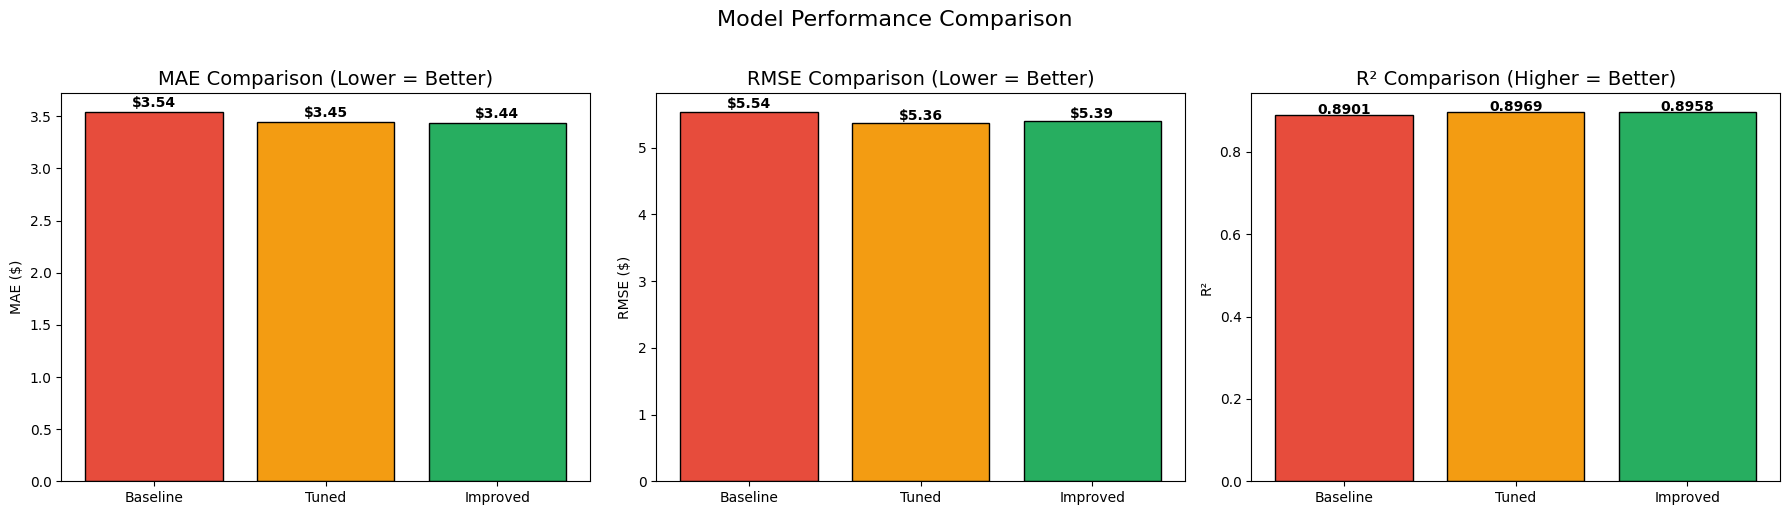

In [8]:
models = ['Baseline', 'Tuned', 'Improved']
mae_scores = [
    mean_absolute_error(y_test, baseline_preds),
    mean_absolute_error(y_test, tuned_preds),
    mean_absolute_error(y_test, improved_preds)
]
rmse_scores = [
    np.sqrt(mean_squared_error(y_test, baseline_preds)),
    np.sqrt(mean_squared_error(y_test, tuned_preds)),
    np.sqrt(mean_squared_error(y_test, improved_preds))
]
r2_scores = [
    r2_score(y_test, baseline_preds),
    r2_score(y_test, tuned_preds),
    r2_score(y_test, improved_preds)
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#e74c3c', '#f39c12', '#27ae60']

# MAE
axes[0].bar(models, mae_scores, color=colors, edgecolor='black')
axes[0].set_title('MAE Comparison (Lower = Better)', fontsize=14)
axes[0].set_ylabel('MAE ($)')
for i, v in enumerate(mae_scores):
    axes[0].text(i, v + 0.05, f'${v:.2f}', ha='center', fontweight='bold')

# RMSE
axes[1].bar(models, rmse_scores, color=colors, edgecolor='black')
axes[1].set_title('RMSE Comparison (Lower = Better)', fontsize=14)
axes[1].set_ylabel('RMSE ($)')
for i, v in enumerate(rmse_scores):
    axes[1].text(i, v + 0.05, f'${v:.2f}', ha='center', fontweight='bold')

# R²
axes[2].bar(models, r2_scores, color=colors, edgecolor='black')
axes[2].set_title('R² Comparison (Higher = Better)', fontsize=14)
axes[2].set_ylabel('R²')
for i, v in enumerate(r2_scores):
    axes[2].text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=16, y=1.02)
plt.savefig("../visualizations/model_comparison.png", bbox_inches='tight')
plt.tight_layout()
plt.show()

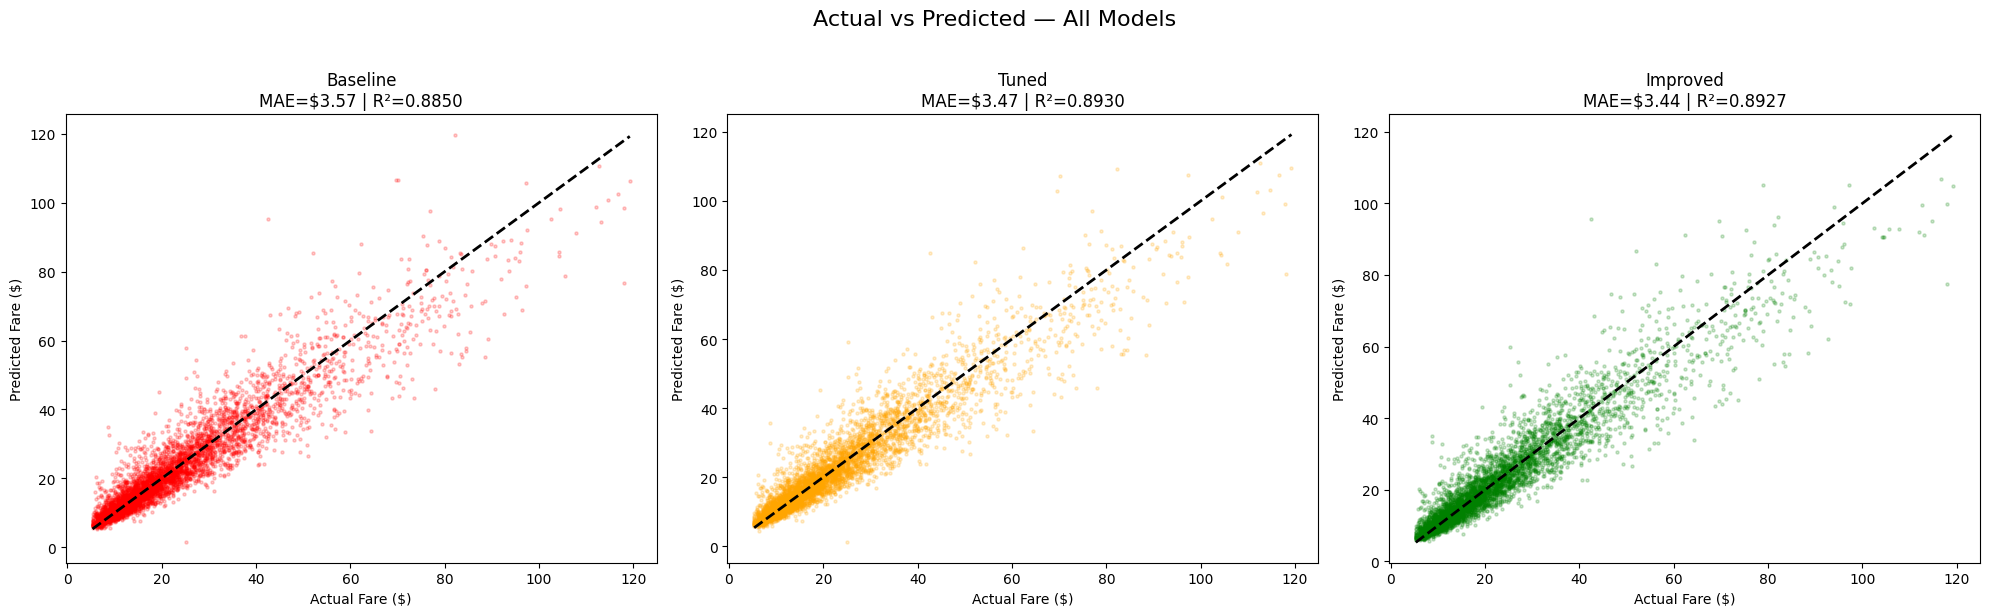

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sample_idx = np.random.choice(len(y_test), 5000, replace=False)
y_sample = y_test.values[sample_idx]

for ax, preds, name, color in zip(
    axes,
    [baseline_preds, tuned_preds, improved_preds],
    ['Baseline', 'Tuned', 'Improved'],
    ['red', 'orange', 'green']
):
    p_sample = preds[sample_idx]
    ax.scatter(y_sample, p_sample, alpha=0.2, s=5, color=color)
    ax.plot([y_sample.min(), y_sample.max()],
            [y_sample.min(), y_sample.max()], 'k--', lw=2)
    ax.set_xlabel('Actual Fare ($)')
    ax.set_ylabel('Predicted Fare ($)')
    r2 = r2_score(y_sample, p_sample)
    mae = mean_absolute_error(y_sample, p_sample)
    ax.set_title(f'{name}\nMAE=${mae:.2f} | R²={r2:.4f}')

plt.suptitle('Actual vs Predicted — All Models', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("../visualizations/actual_vs_predicted.png", bbox_inches='tight')
plt.show()

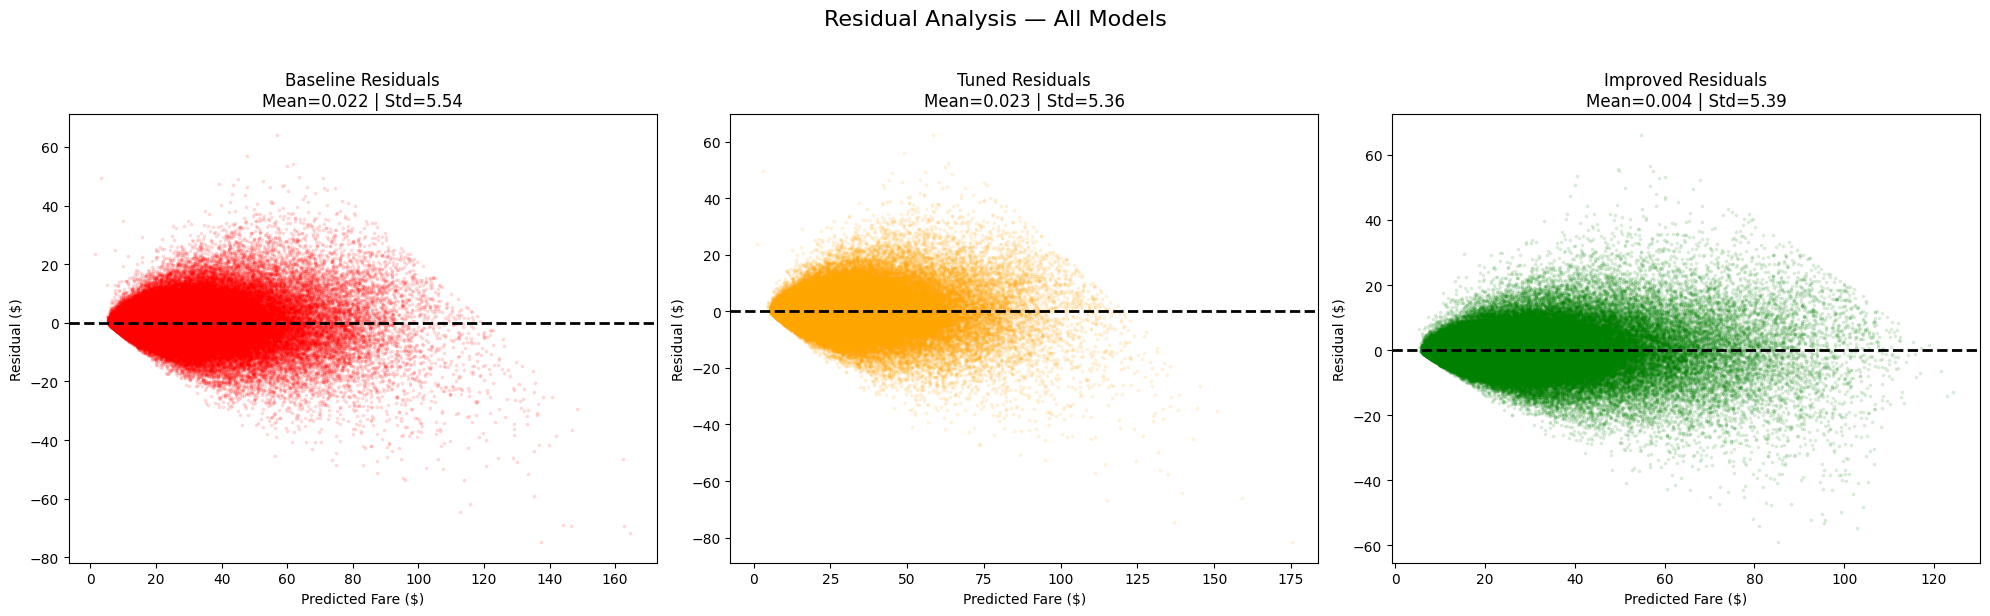

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, preds, name, color in zip(
    axes,
    [baseline_preds, tuned_preds, improved_preds],
    ['Baseline', 'Tuned', 'Improved'],
    ['red', 'orange', 'green']
):
    residuals = y_test.values - preds
    ax.scatter(preds, residuals, alpha=0.1, s=3, color=color)
    ax.axhline(y=0, color='black', linestyle='--', lw=2)
    ax.set_xlabel('Predicted Fare ($)')
    ax.set_ylabel('Residual ($)')
    ax.set_title(f'{name} Residuals\nMean={np.mean(residuals):.3f} | Std={np.std(residuals):.2f}')

plt.suptitle('Residual Analysis — All Models', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("../visualizations/residual_analysis.png", bbox_inches='tight')
plt.show()

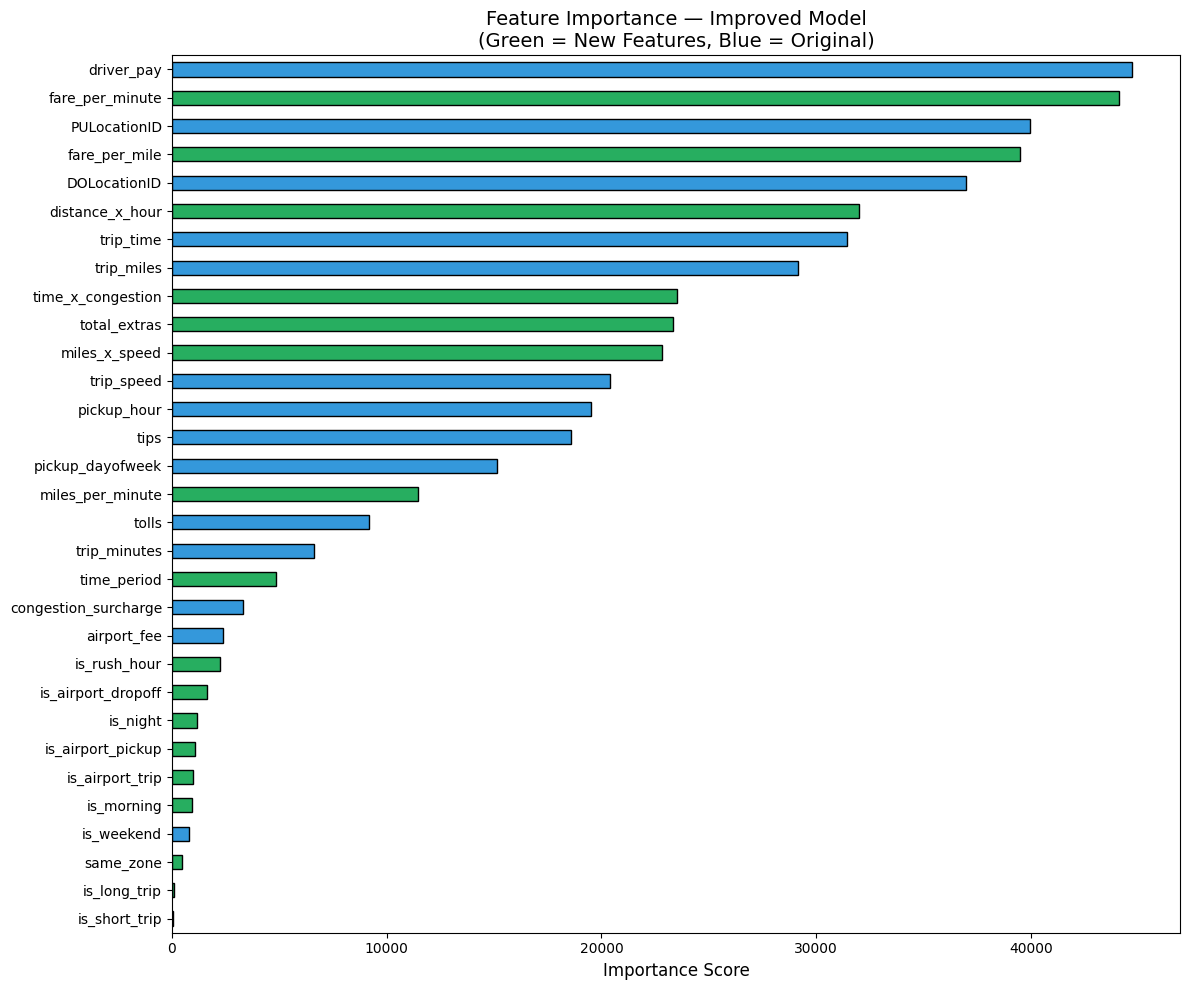

In [11]:
importance = pd.Series(improved_model.feature_importances_, index=all_features)
importance = importance.sort_values(ascending=True)

colors_fi = ['#27ae60' if f in new_features else '#3498db' for f in importance.index]

plt.figure(figsize=(12, 10))
importance.plot(kind='barh', color=colors_fi, edgecolor='black')
plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance — Improved Model\n(Green = New Features, Blue = Original)',
          fontsize=14)
plt.tight_layout()
plt.savefig("../visualizations/feature_importance.png", bbox_inches='tight')
plt.show()

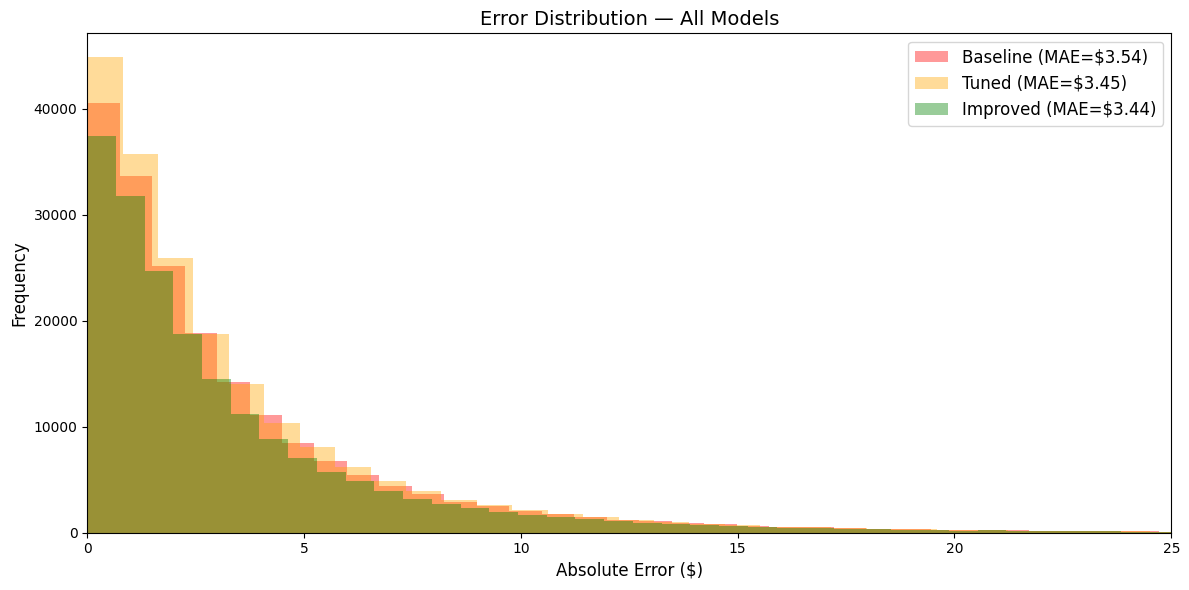

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

baseline_errors = np.abs(y_test.values - baseline_preds)
tuned_errors = np.abs(y_test.values - tuned_preds)
improved_errors = np.abs(y_test.values - improved_preds)

ax.hist(baseline_errors, bins=100, alpha=0.4, label=f'Baseline (MAE=${np.mean(baseline_errors):.2f})', color='red')
ax.hist(tuned_errors, bins=100, alpha=0.4, label=f'Tuned (MAE=${np.mean(tuned_errors):.2f})', color='orange')
ax.hist(improved_errors, bins=100, alpha=0.4, label=f'Improved (MAE=${np.mean(improved_errors):.2f})', color='green')

ax.set_xlabel('Absolute Error ($)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Error Distribution — All Models', fontsize=14)
ax.legend(fontsize=12)
ax.set_xlim(0, 25)
plt.tight_layout()
plt.savefig("../visualizations/error_distribution.png", bbox_inches='tight')
plt.show()

In [7]:
sample = pd.DataFrame({
    'Actual': y_test.head(10).values.round(2),
    'Baseline': baseline_preds[:10].round(2),
    'Tuned': tuned_preds[:10].round(2),
    'Improved': improved_preds[:10].round(2),
    'Baseline_Error': np.abs(y_test.head(10).values - baseline_preds[:10]).round(2),
    'Improved_Error': np.abs(y_test.head(10).values - improved_preds[:10]).round(2),
})

print("📊 Sample Predictions:")
print(sample.to_string(index=False))

📊 Sample Predictions:
 Actual  Baseline  Tuned  Improved  Baseline_Error  Improved_Error
  17.33     19.86  20.16     20.91            2.53            3.58
   6.74     15.27  14.61     13.92            8.53            7.18
  31.35     25.89  26.52     26.99            5.46            4.36
  27.95     19.58  19.88     19.43            8.37            8.52
  21.59     28.84  29.08     27.81            7.25            6.22
  21.04     24.87  25.19     25.91            3.83            4.87
  18.83     19.45  20.11     19.32            0.62            0.49
  16.04     20.04  19.85     20.12            4.00            4.08
  84.21     72.46  73.52     75.66           11.75            8.55
   9.86      9.03   9.03      9.37            0.83            0.49
